# QR Algorithm (QR Iteration)

The QR algorithm is a numerical method used to calculate the eigenvalues and eigenvectors of a matrix.
The QR algorithm is one of the most important numerical methods for computing **eigenvalues** and **eigenvectors**.

QR decomposition by writing the matrix as a product of an **unitary matrix** and an **upper triangular matrix**. The factors are then multiplied in reverse order, and this process is repeated iteratively.


## QR Decomposition

A = QR


where:

- Q is a unitary matrix
- R is an upper triangular matrix

The QR algorithm iteratively computes QR decompositions:

**<u>QR Algorithm</u>**

$$
\begin{array}{cl}
\left.
\begin{aligned}
A_0 &= Q_0 R_0 \\
A_1 &= R_0 Q_0 \\
A_1 &= Q_1 R_1 \\
A_2 &= R_1 Q_1 
\end{aligned}
\right\} 
& \longrightarrow 
\begin{array}{l}
A_0, A_1, A_2, \dots, A_n \\
\text{will have the} \\
\text{same} \\
\text{eigenvalues}
\end{array} \\[4ex]
\vdots & \\[1ex]
\begin{array}{|c|}
\hline
A_n = Q_n R_n \\
A_{n+1} = R_n Q_n \\
\hline
\end{array} &
\end{array}
$$

An algorithm for computing \(Q\) and \(R\) from a given matrix \(A\) is known.

Using

$$
R_n = Q_n^{-1} A_{n-1},
$$

one obtains

$$
A_n = R_n Q_n = Q_n^{-1} A_{n-1} Q_n.
$$

Therefore, each iteration is a similarity transformation.

The sequence

Series $A_0, A_1, A_2 \dots$ **converges to a diagonal matrix** $D$  
off-diagonal elements decay as

$$a_{ij}^{(k)} \sim \left| \frac{\lambda_i}{\lambda_j} \right|^k \qquad \begin{aligned} &\text{where wlog } i < j \text{ and} \\ &\text{sorted eigenvalues } \lambda_1 \gg \lambda_2 \gg \dots \\ &\text{are assumed.} \end{aligned}$$

Hence, the QR algorithm produces an approximate eigenvalue decomposition:

$$
D \approx A_n
=
R_n Q_n
=
Q_n^{-1} A_{n-1} Q_n
=
\cdots
=
\underbrace{Q_n^{-1}\cdots Q_1^{-1}}_{U^\dagger}
A
\underbrace{Q_1 \cdots Q_n}_{U}.
$$

The columns of \(U\) approximate the eigenvectors of \(A\), while the diagonal entries of \(D\) approximate the eigenvalues.



Let's begin with the $QR$ decomposition...

$A = QR$

With $Q$ being an orthonormal matrix  recall that $Q^T Q = Q Q^T = I$, so $Q^T=Q^{-1}$.

Let's then say $B = RQ$. From this we can play quite an clever trick with our $QR$ decomposition of $A$ and the porperties of orthonormal matrices.

$B = RQ$

$IB = IRQ$ 

$B = Q^{T}QRQ$

$B = Q^{-1}QRQ$ (Remember $A = QR$)

$B = Q^{-1}AQ$ (This is the Schur Decomposition)

So with this we can say $B$ and $A$ are similar matrices. Further, by examining how we get the Schur decomposition we can see a way of producing an similar matrix for $A$ provided that we can perform a $QR$ decomposition for $A$.
That is that we can just compute $RQ$ and we will have a similar matrix.

To show or check that two similar matrices have the same eigenvalues, below we'll use `np.linalg.eig()` and `np.linalg.qr()` to confirm that $A$ and $B$ have the same eigenvalues.

In [1]:
import numpy as np

In [2]:
A = np.array(np.random.randint (0, 100, (3, 3)), dtype=np.float64)
print(f"A:\n {A}")
A_eigvals, A_eigvecs = np.linalg.eig(A)
print(f"Eigenvalues for A: \n {A_eigvals}")

Q, R = np.linalg.qr(A)
B = np.dot(R, Q)
print(f"RQ = B: \n {B}")
B_eigvals, B_eigvecs = np.linalg.eig(B)
print(f"Eigenvalues for B: \n {B_eigvals}")

A:
 [[41. 81. 72.]
 [55. 82. 96.]
 [37. 81. 53.]]
Eigenvalues for A: 
 [201.24303463+0.j  -2.96140309+0.j -22.28163154+0.j]
RQ = B: 
 [[201.11209877 -15.34886952 -42.37273135]
 [-13.02311644 -20.73893426  -0.2290595 ]
 [  3.46018321  -4.69390158  -4.37316451]]
Eigenvalues for B: 
 [201.24303463+0.j -22.28163154+0.j  -2.96140309+0.j]


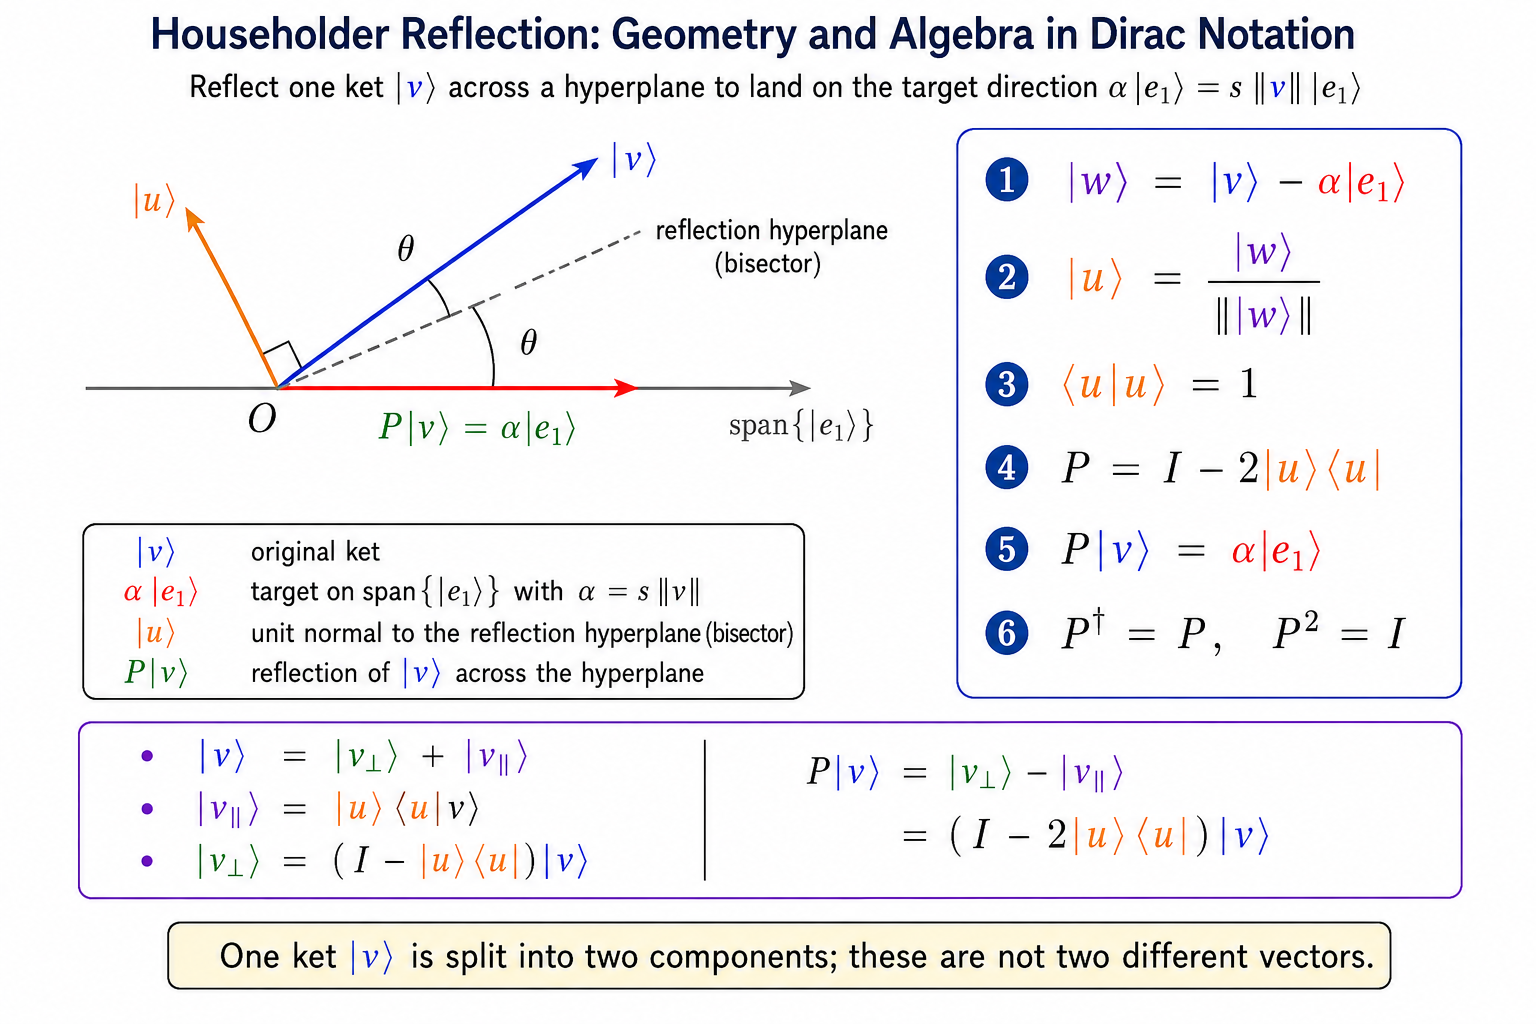!

In [6]:
def householder_QR(A):
    """
    Calculate A = QR using Householder reflections.
    """

    A = np.asarray(A, dtype=float)
    m, n = A.shape
    R = A.copy()
    Q = np.eye(m)

    for k in range(min(m, n)):
        # Part of column k that must be transformed
        x = R[k:, k]

        # Skip an already-zero column
        if np.linalg.norm(x) == 0:
            continue

        # Stable choice of alpha
        sign = 1.0 if x[0] >= 0 else -1.0
        alpha = -sign * np.linalg.norm(x)

        # Construct and normalize the Householder vector
        e1 = np.zeros_like(x)
        e1[0] = 1.0

        w = x - alpha * e1
        u = w / np.linalg.norm(w)

        # Small Householder operator
        P_small = np.eye(len(x)) - 2 * np.outer(u, u)

        # Embed it into an m × m operator
        P = np.eye(m)
        P[k:, k:] = P_small

        # Apply P from the left to produce R
        R = P @ R

        # Accumulate Q
        Q = Q @ P

    # Remove tiny floating-point values
    R[np.abs(R) < 1e-12] = 0.0
    Q[np.abs(Q) < 1e-12] = 0.0

    return Q, R


A = np.array([
    [12.0, -51.0,   4.0],
    [ 6.0, 167.0, -68.0],
    [-4.0,  24.0, -41.0]
])

Q, R = householder_QR(A)

print("Matrix A:")
print(A)

print("\nOrthogonal matrix Q:")
print(Q)

print("\nUpper-triangular matrix R:")
print(R)

print("\nCheck A = QR:")
print(Q @ R)

print("\nIs Q orthogonal?")
print(np.allclose(Q.T @ Q, np.eye(Q.shape[0])))

print("\nDoes QR reproduce A?")
print(np.allclose(Q @ R, A))

Matrix A:
[[ 12. -51.   4.]
 [  6. 167. -68.]
 [ -4.  24. -41.]]

Orthogonal matrix Q:
[[-0.85714286  0.39428571 -0.33142857]
 [-0.42857143 -0.90285714  0.03428571]
 [ 0.28571429 -0.17142857 -0.94285714]]

Upper-triangular matrix R:
[[ -14.  -21.   14.]
 [   0. -175.   70.]
 [   0.    0.   35.]]

Check A = QR:
[[ 12. -51.   4.]
 [  6. 167. -68.]
 [ -4.  24. -41.]]

Is Q orthogonal?
True

Does QR reproduce A?
True


## QR algorithm: computational cost

For a dense Hermitian matrix $A$ of size $N\times N$:

| Stage | Operation | Cost |
|---|---|---|
| 1. Householder reduction | Transform $A$ into tridiagonal form | $O(N^3)$, once |
| 2. QR iteration | Repeatedly make the tridiagonal matrix closer to diagonal | Approximately $O(N^2)$ per sweep |

The first stage is expensive, but it is performed only once. The QR
sweeps are cheaper individually; their total cost depends on how many
sweeps are needed. Closely spaced eigenvalues can slow convergence.
Using shifts can speed it up.

First reduce the dense Hermitian matrix to
tridiagonal form using Householder transformations. Then apply QR
iterations until the off-diagonal entries become small. The initial
reduction has cubic cost, while each subsequent sweep exploits the
tridiagonal structure.